# **Classification Project:** MNIST
29/03/2026, Louie Leverett

In [59]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
plt.style.use('dark_background')

### Extract mnist dataset and display sample of figures

In [60]:
mnist = fetch_openml('mnist_784', parser='pandas')

In [61]:
X, y = mnist["data"].to_numpy(), mnist["target"].to_numpy()
print(mnist.keys())
print(f"Num images: {X.shape[0]}, Num features (pixels): {X.shape[1]}")

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
Num images: 70000, Num features (pixels): 784


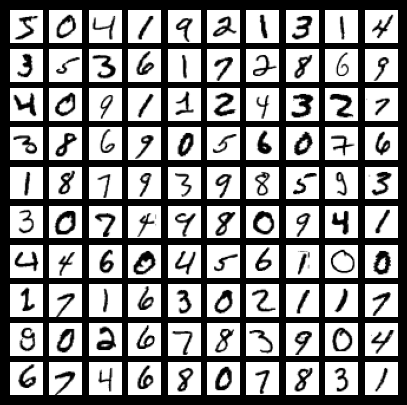

In [62]:
# display sample of digits
fig, axis = plt.subplots(10, 10, figsize=(5, 5))
labels = ""
for i, ax in enumerate(axis.flat):
    example_digit = X[i].reshape(28, 28)
    labels = labels + f"{y[i]}, "
    ax.imshow(example_digit, cmap='binary');
    ax.axis("off")
# print(labels)

Histogram of labels

### Evaluate distribution of figures

In [63]:
import numpy as np
from matplotlib.ticker import PercentFormatter

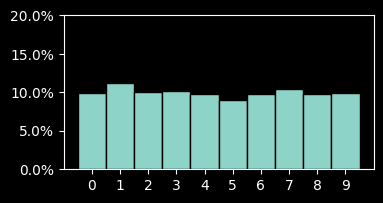

In [64]:
yy = np.sort(y)
plt.figure(figsize=(4, 2))
plt.hist(yy, weights=np.ones(len(y)) / len(y), bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], align="left", edgecolor = "black")
plt.ylim(0.0, 0.2)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

### Create training and test sets

Training set = first 60,0000; Test set = last 10,000 images

**Note:** the training set is already shuffled

In [65]:
X_train, X_test, y_train, y_test = X[:60_000], X[60_000:], y[:60_000], y[60_000:]

In [66]:
X_train = X_train[:2000]
y_train = y_train[:2000]

### Select and Train a Model

In [67]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay


from sklearn.linear_model import SGDClassifier

In [68]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("ignore", category=ConvergenceWarning)

Preprocessing pipeline

[0.83058471 0.81109445 0.85585586]


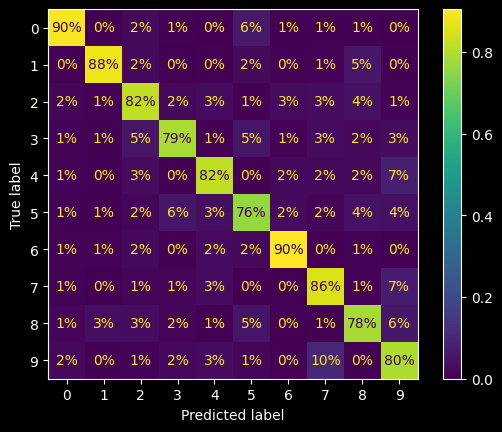

In [69]:
preprocessing = make_pipeline(StandardScaler())

sgd_classifier = Pipeline([
    ("preprocessing", preprocessing),
    ("SGD_Classifier", SGDClassifier(random_state=42)),
])

sgd_accuracy = cross_val_score(
    sgd_classifier, 
    X_train, 
    y_train, 
    cv=3, scoring="accuracy"
)
print(sgd_accuracy)

y_train_predictions = cross_val_predict(
    sgd_classifier, 
    X_train, 
    y_train, 
    cv=3,
)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_predictions, normalize="true", values_format=".0%")
plt.show()


In [70]:
sgd_classifier.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('SGD_Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and wi

In [71]:
prediction = sgd_classifier.predict([X[i]])
label = y[i]
print(f"{prediction==label}, Prediction: {prediction}, Actual: {label}")

[ True], Prediction: ['1'], Actual: 1
